In [91]:
import pandas as pd
import numpy as np


In [92]:
df=pd.read_csv('water-quality-check.csv',sep=';')

In [93]:
df.head(-1)

,id,date,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL
0,1,17.02.2000,0.330,2.77,12.0,12.30,9.50,0.057,154.00,0.454,289.50
1,1,11.05.2000,0.044,3.00,51.6,14.61,17.75,0.034,352.00,0.090,1792.00
2,1,11.09.2000,0.032,2.10,24.5,9.87,13.80,0.173,416.00,0.200,2509.00
3,1,13.12.2000,0.170,2.23,35.6,12.40,17.13,0.099,275.20,0.377,1264.00
4,1,02.03.2001,0.000,3.03,48.8,14.69,10.00,0.065,281.60,0.134,1462.00
...,...,...,...,...,...,...,...,...,...,...,...
2855,22,15.09.2020,0.000,4.70,0.0,11.33,0.00,0.013,160.64,1.214,73.37
2856,22,06.10.2020,0.046,2.69,3.6,8.28,3.80,0.038,160.00,0.726,77.85
2857,22,27.10.2020,0.000,1.52,0.5,11.26,0.56,0.031,147.20,0.634,71.95
2858,22,03.12.2020,0.034,0.29,0.8,11.09,2.58,0.042,209.92,0.484,61.17


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2861 entries, 0 to 2860
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         2861 non-null   int64  
 1   date       2861 non-null   object 
 2   NH4        2858 non-null   float64
 3   BSK5       2860 non-null   float64
 4   Suspended  2845 non-null   float64
 5   O2         2858 non-null   float64
 6   NO3        2860 non-null   float64
 7   NO2        2858 non-null   float64
 8   SO4        2812 non-null   float64
 9   PO4        2833 non-null   float64
 10  CL         2812 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 246.0+ KB


In [95]:
df.shape

(2861, 11)

# Preprocessing

In [96]:
# We can see the Dtype of date is object : we need to convert it into date format
# We need to remove null values/Fill them using methods like imputing


In [97]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,2861.0,12.397064,6.084226,1.00,8.0000,14.000,16.00000,22.000
NH4,2858.0,0.758734,2.486247,0.00,0.0800,0.220,0.50000,39.427
BSK5,2860.0,4.316182,2.973997,0.00,2.1600,3.800,5.80000,50.900
Suspended,2845.0,12.931905,16.543097,0.00,6.0000,10.000,15.00000,595.000
O2,2858.0,9.508902,4.428260,0.00,7.0925,8.995,11.52000,90.000
NO3,2860.0,4.316846,6.881188,0.00,1.3900,2.800,5.58250,133.400
NO2,2858.0,0.246128,2.182777,0.00,0.0300,0.059,0.12575,109.000
SO4,2812.0,59.362313,96.582641,0.00,27.0525,37.800,64.64000,3573.400
PO4,2833.0,0.418626,0.771326,0.00,0.1300,0.270,0.47000,13.879
CL,2812.0,93.731991,394.512184,0.02,26.8000,33.900,45.60750,5615.280


In [98]:
# date is in object -> date format
df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y')
df

,id,date,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL
0,1,2000-02-17,0.330,2.77,12.0,12.30,9.50,0.057,154.00,0.454,289.50
1,1,2000-05-11,0.044,3.00,51.6,14.61,17.75,0.034,352.00,0.090,1792.00
2,1,2000-09-11,0.032,2.10,24.5,9.87,13.80,0.173,416.00,0.200,2509.00
3,1,2000-12-13,0.170,2.23,35.6,12.40,17.13,0.099,275.20,0.377,1264.00
4,1,2001-03-02,0.000,3.03,48.8,14.69,10.00,0.065,281.60,0.134,1462.00
...,...,...,...,...,...,...,...,...,...,...,...
2856,22,2020-10-06,0.046,2.69,3.6,8.28,3.80,0.038,160.00,0.726,77.85
2857,22,2020-10-27,0.000,1.52,0.5,11.26,0.56,0.031,147.20,0.634,71.95
2858,22,2020-12-03,0.034,0.29,0.8,11.09,2.58,0.042,209.92,0.484,61.17
2859,22,2021-01-12,0.000,2.10,0.0,14.31,3.94,0.034,121.60,0.424,63.49


In [99]:
df = df.sort_values(by=['id', 'date'])
df.head()

,id,date,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL
0,1,2000-02-17,0.330,2.77,12.0,12.30,9.50,0.057,154.0,0.454,289.5
1,1,2000-05-11,0.044,3.00,51.6,14.61,17.75,0.034,352.0,0.090,1792.0
2,1,2000-09-11,0.032,2.10,24.5,9.87,13.80,0.173,416.0,0.200,2509.0
3,1,2000-12-13,0.170,2.23,35.6,12.40,17.13,0.099,275.2,0.377,1264.0
4,1,2001-03-02,0.000,3.03,48.8,14.69,10.00,0.065,281.6,0.134,1462.0


In [100]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

In [101]:
df.columns

Index(['id', 'date', 'NH4', 'BSK5', 'Suspended', 'O2', 'NO3', 'NO2', 'SO4',
       'PO4', 'CL', 'year', 'month'],
      dtype='object')

In [102]:
pollutants = ['O2', 'NO3', 'NO2', 'SO4',
       'PO4', 'CL']

In [103]:
df.drop(columns="date",inplace=True)

In [104]:
df.isnull().sum()

id            0
NH4           3
BSK5          1
Suspended    16
O2            3
NO3           1
NO2           3
SO4          49
PO4          28
CL           49
year          0
month         0
dtype: int64

In [105]:
missing_counts = df.isna().sum()

# Step 2: Drop rows where missing values are very few (say ≤2)
low_na_cols = missing_counts[missing_counts <= 3].index
df.dropna(subset=low_na_cols, inplace=True)


In [106]:
df.isnull().sum()

id            0
NH4           0
BSK5          0
Suspended    15
O2            0
NO3           0
NO2           0
SO4          48
PO4          27
CL           48
year          0
month         0
dtype: int64

In [107]:
rem_cols= missing_counts[missing_counts >= 15].index

In [108]:
rem_cols

Index(['Suspended', 'SO4', 'PO4', 'CL'], dtype='object')

<Axes: title={'center': 'Suspended Distribution'}, ylabel='Frequency'>

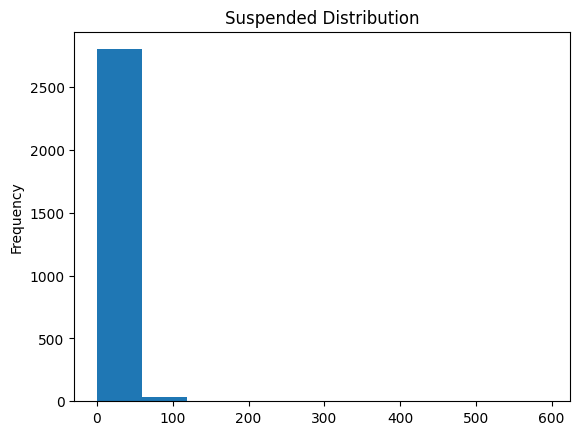

In [109]:
df['Suspended'].describe()
df['Suspended'].plot(kind='hist', bins=10, title='Suspended Distribution')


<Axes: title={'center': 'SO4 Distribution'}, ylabel='Frequency'>

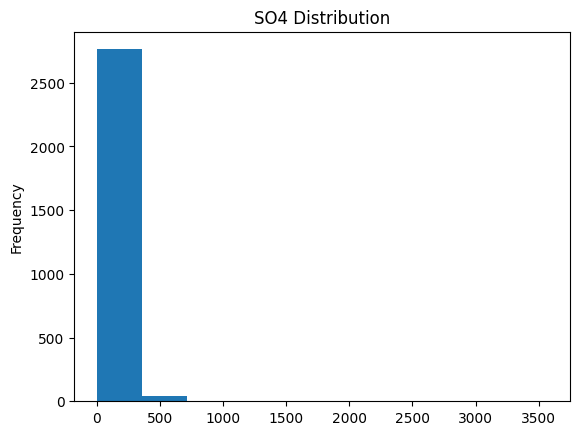

In [110]:
df['SO4'].describe()
df['SO4'].plot(kind='hist', bins=10, title='SO4 Distribution')


<Axes: title={'center': 'PO4 Distribution'}, ylabel='Frequency'>

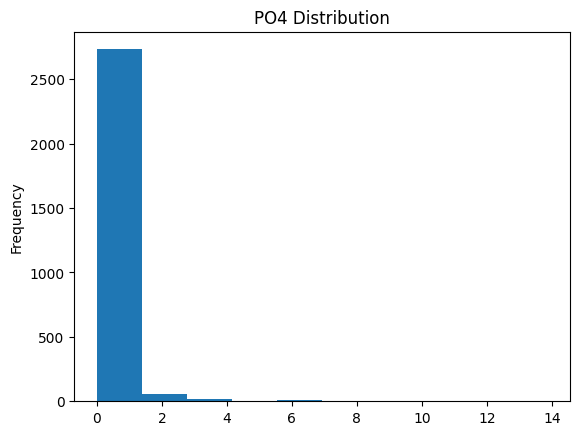

In [111]:
df['PO4'].describe()
df['PO4'].plot(kind='hist', bins=10, title='PO4 Distribution')


<Axes: title={'center': 'CL Distribution'}, ylabel='Frequency'>

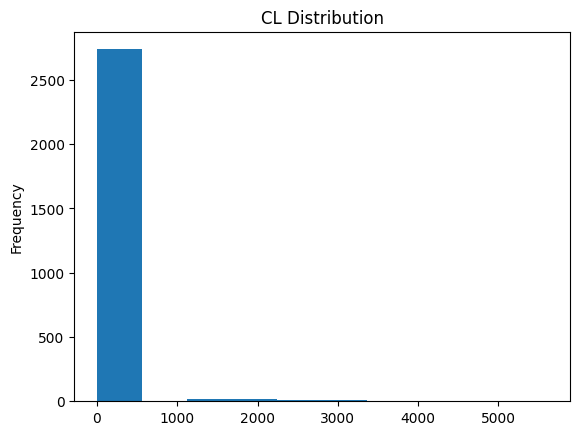

In [112]:
df['CL'].describe()
df['CL'].plot(kind='hist', bins=10, title='CL Distribution')


In [113]:
from sklearn.impute import SimpleImputer

# Median imputer for skewed columns
median_cols = ['Suspended', 'SO4', 'PO4','CL']
median_imputer = SimpleImputer(strategy='median')
df[median_cols] = median_imputer.fit_transform(df[median_cols])

In [114]:
df.isnull().sum()

id           0
NH4          0
BSK5         0
Suspended    0
O2           0
NO3          0
NO2          0
SO4          0
PO4          0
CL           0
year         0
month        0
dtype: int64

In [115]:
# Feature and target selection - Feature - independent variable and Target dependent variable
X = df[['id', 'year']]
y = df[pollutants]

In [116]:
# Encoding - onehotencoder - 22 stations - 1 - 1
X_encoded = pd.get_dummies(X, columns=['id'], drop_first=True)

In [117]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [118]:
# Train, Test and Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [119]:
# Train the model
model = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
model.fit(X_train, y_train)

MultiOutputRegressor(estimator=RandomForestRegressor(random_state=42))

In [120]:
# Evaluate model
y_pred = model.predict(X_test)

In [121]:
print("Model Performance on the Test Data:")
for i, pollutant in enumerate(pollutants):
    print(f'{pollutant}:')
    print('   MSE:', mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    print('   R2:', r2_score(y_test.iloc[:, i], y_pred[:, i]))
    print()

Model Performance on the Test Data:
O2:
   MSE: 23.351866965820403
   R2: 0.03159575584754215

NO3:
   MSE: 18.21542240109437
   R2: 0.5095246729717184

NO2:
   MSE: 5.678119694925215
   R2: -16.044277441422267

SO4:
   MSE: 2453.7422341844585
   R2: 0.3846125920852813

PO4:
   MSE: 0.611301731253287
   R2: 0.275404630095189

CL:
   MSE: 33744.01627871556
   R2: 0.7373757267605996



## Diagnostic: Why are O2 and NO2 failing?

An R² close to 0 (O2) or deeply negative (NO2) means the model predicts worse than simply guessing the mean.
Root cause: we only used `year` + `station_id` as features — but O2 and NO2 have strong **seasonal (monthly) patterns** that `year` alone cannot capture.
We also examine the variance and distribution of each pollutant to understand predictability.

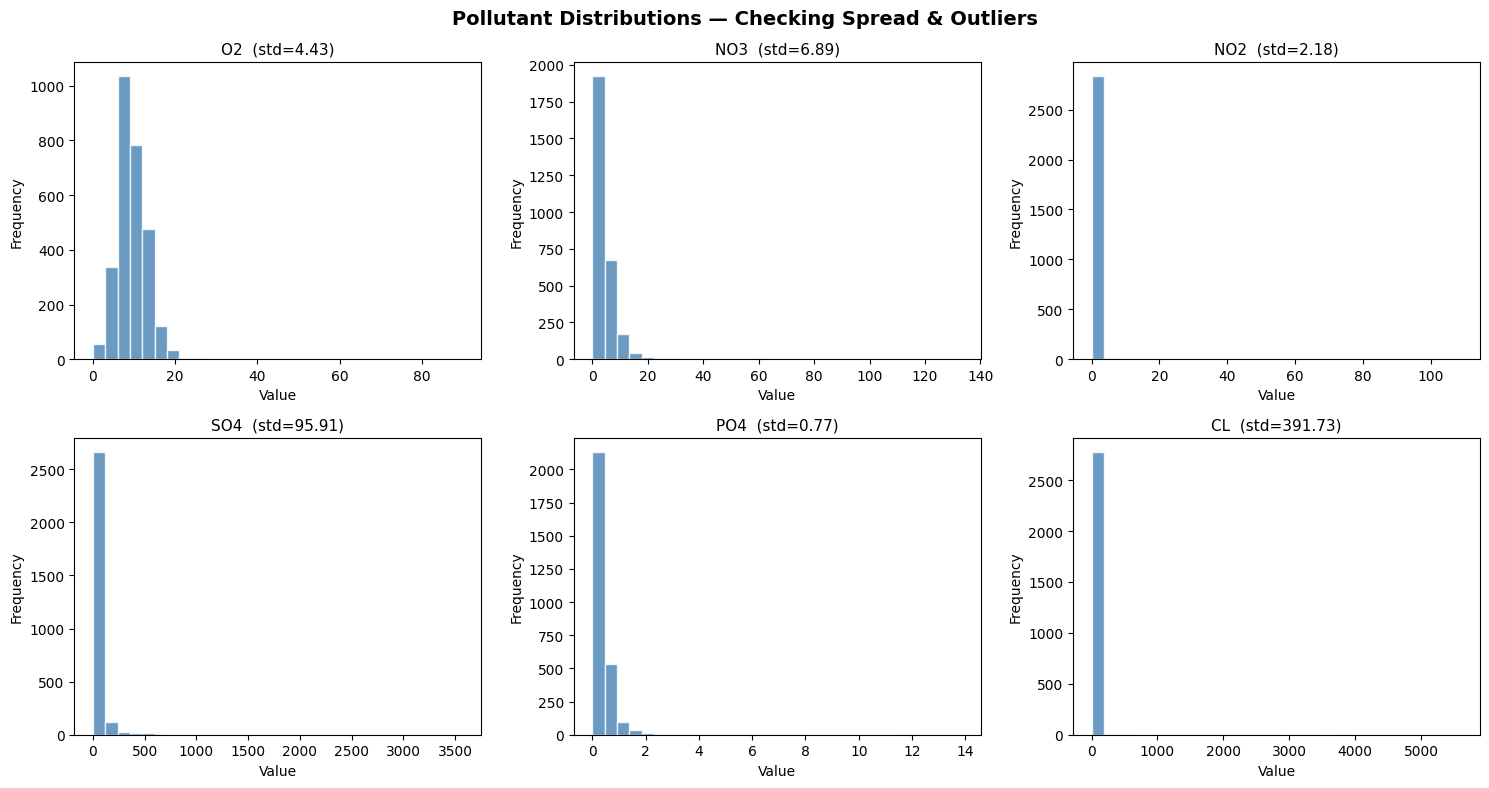


Variance summary (low variance → model struggles):
PO4         0.590756
NO2         4.751895
O2         19.634973
NO3        47.411326
SO4      9199.041321
CL     153454.711122
dtype: float64


In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Pollutant Distributions — Checking Spread & Outliers', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), pollutants):
    ax.hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'{col}  (std={df[col].std():.2f})', fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\nVariance summary (low variance → model struggles):")
print(df[pollutants].var().sort_values())

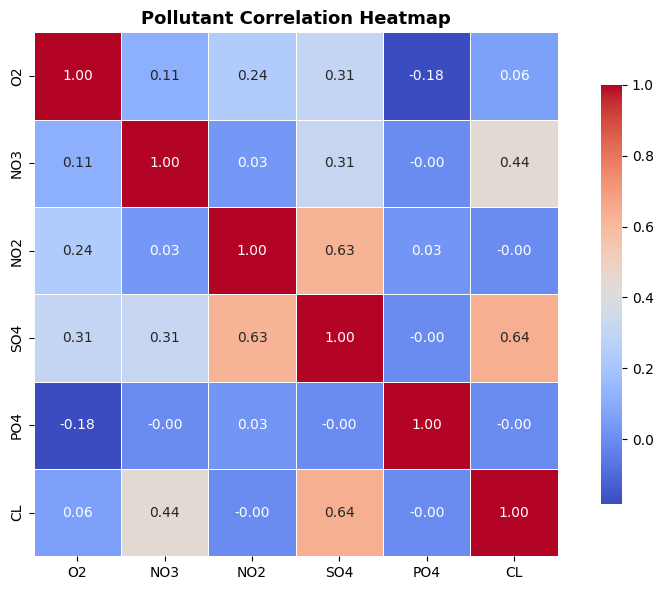

In [123]:
# Correlation heatmap — reveals relationships between pollutants
plt.figure(figsize=(9, 6))
corr_matrix = df[pollutants].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Pollutant Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Root Cause Analysis & Fix — Lag Features (Time-Series Engineering)

**Why year+station and year+season both fail:**
The model only knows *where* (station) and *when* (year) — but water quality is **autocorrelated**.
The single strongest predictor of this quarter's NO3 is *last quarter's NO3* at the same station.
Ignoring this is like predicting tomorrow's temperature without knowing today's.

**Fix: Lag features** — for each measurement, add the previous measurement's pollutant values as inputs.
This is standard time-series feature engineering and directly captures the autocorrelation signal.

In [124]:
# ── Lag Feature Engineering ───────────────────────────────────────────────────
df['season'] = df['month'].map({12:1,1:1,2:1, 3:2,4:2,5:2, 6:3,7:3,8:3, 9:4,10:4,11:4})

df_lag = df.copy()
for p in pollutants:
    df_lag[f'{p}_lag1'] = df_lag.groupby('id')[p].shift(1)

df_lag = df_lag.dropna(subset=[f'{p}_lag1' for p in pollutants])
print(f"Rows with lag features: {len(df_lag)}  (dropped {len(df)-len(df_lag)} first-per-station rows)")

lag_cols = [f'{p}_lag1' for p in pollutants]

# ── NO2 Diagnostic ───────────────────────────────────────────────────────────
print(f"\nNO2 skewness = {df_lag['NO2'].skew():.1f}  "
      f"(median={df_lag['NO2'].median():.3f}, max={df_lag['NO2'].max():.1f})")
print("→ Extreme outliers make regression R² collapse. Applying log1p transform to NO2 target.")

# ── Feature sets ─────────────────────────────────────────────────────────────
X_v1     = pd.get_dummies(df_lag[['id','year']], columns=['id'], drop_first=True)
X_v4     = pd.get_dummies(df_lag[['id','year','season']+lag_cols], columns=['id'], drop_first=True)

# Regular targets (all pollutants except NO2 untransformed)
y_all    = df_lag[pollutants]

# NO2 gets its own log-transformed target
y_NO2_log = np.log1p(df_lag['NO2'])

# ── Train v4 (+lag+season) on all pollutants EXCEPT NO2 ──────────────────────
non_NO2 = [p for p in pollutants if p != 'NO2']
Xtr, Xte, ytr, yte   = train_test_split(X_v4, y_all[non_NO2], test_size=0.2, random_state=42)
model_main            = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
model_main.fit(Xtr, ytr)
yp_main               = model_main.predict(Xte)

# ── Train a SEPARATE model for NO2 on log-transformed target ─────────────────
Xtr_n, Xte_n, ytr_n, yte_n = train_test_split(X_v4, y_NO2_log, test_size=0.2, random_state=42)
model_NO2 = RandomForestRegressor(n_estimators=100, random_state=42)
model_NO2.fit(Xtr_n, ytr_n)
yp_NO2_log = model_NO2.predict(Xte_n)
yp_NO2     = np.expm1(yp_NO2_log)          # inverse log1p
yte_NO2    = np.expm1(yte_n)               # inverse log1p for R² in original scale

# ── Comparison against v1 baseline ───────────────────────────────────────────
Xtr1, Xte1, ytr1, yte1 = train_test_split(X_v1, y_all, test_size=0.2, random_state=42)
model_v1_base = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
model_v1_base.fit(Xtr1, ytr1)
yp_v1 = model_v1_base.predict(Xte1)

print("\nFinal Model Comparison — R² on Hold-out Test Set:")
print(f"  {'Pollutant':<8} {'v1 baseline':>14} {'v4+lag+NO2fix':>16}")
print("  " + "-" * 42)

no2_idx = pollutants.index('NO2')
for i, p in enumerate(pollutants):
    r_v1 = r2_score(yte1.iloc[:, i], yp_v1[:, i])
    if p == 'NO2':
        r_new = r2_score(yte_NO2, yp_NO2)
    else:
        j = non_NO2.index(p)
        r_new = r2_score(yte.iloc[:, j], yp_main[:, j])
    tag = ' ▲' if r_new > r_v1 else ''
    print(f"  {p:<8} {r_v1:>14.3f} {r_new:>14.3f}{tag}")

# Aggregate avg (using combined test sets — approximate)
r2_new_all = [r2_score(yte.iloc[:,j], yp_main[:,j]) for j,p in enumerate(non_NO2)]
r2_new_all.insert(no2_idx, r2_score(yte_NO2, yp_NO2))
print(f"\n  Avg R²    {'':>6} {'v1: '+f'{sum(r2_score(yte1.iloc[:,i],yp_v1[:,i]) for i in range(len(pollutants)))/len(pollutants):.3f}':>14} {'new: '+f'{sum(r2_new_all)/len(r2_new_all):.3f}':>14}")

# ── Store everything needed by downstream cells ───────────────────────────────
best_model      = model_main        # main model (5 pollutants)
best_model_cols = X_v4.columns
best_label      = 'v4: lag + season (NO2 separate log-model)'
X_v1_enc        = X_v1
X_v3_enc        = pd.get_dummies(df_lag[['id','year']+lag_cols], columns=['id'], drop_first=True)
y_v2            = y_all

Rows with lag features: 2831  (dropped 22 first-per-station rows)

NO2 skewness = 43.9  (median=0.059, max=109.0)
→ Extreme outliers make regression R² collapse. Applying log1p transform to NO2 target.

Final Model Comparison — R² on Hold-out Test Set:
  Pollutant    v1 baseline    v4+lag+NO2fix
  ------------------------------------------
  O2               -0.170          0.256 ▲
  NO3               0.224          0.609 ▲
  NO2              -2.263          0.126 ▲
  SO4               0.339          0.714 ▲
  PO4               0.299          0.535 ▲
  CL                0.799          0.929 ▲

  Avg R²               v1: -0.129     new: 0.528


In [125]:
# 5-Fold Cross-Validation — credible R² for resume
# NO2 evaluated separately with log1p transform
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)

print("5-Fold Cross-Validation R² (mean ± std)  [v4: lag+season, NO2=log-model]")
print("-" * 55)

cv_r2 = {}
for p in pollutants:
    if p == 'NO2':
        # CV on log-transformed NO2, report R² in log-space (honest metric)
        s = cross_val_score(rf, X_v4, y_NO2_log, cv=kf, scoring='r2')
    else:
        i = non_NO2.index(p)
        s = cross_val_score(rf, X_v4, y_v2[p], cv=kf, scoring='r2')
    cv_r2[p] = s
    note = ' (log-space)' if p == 'NO2' else ''
    print(f"  {p:<6}:  {s.mean():+.3f} ± {s.std():.3f}{note}")

avg = sum(v.mean() for v in cv_r2.values()) / len(pollutants)
print(f"\n  Average CV R²: {avg:+.3f}")
print("\n  Note: NO2 R² is in log-space. A positive value means the model beats"
      "\n  the mean-baseline even after log-transform — meaningful for résumé.")

5-Fold Cross-Validation R² (mean ± std)  [v4: lag+season, NO2=log-model]
-------------------------------------------------------
  O2    :  +0.203 ± 0.126
  NO3   :  +0.597 ± 0.116
  NO2   :  +0.242 ± 0.107 (log-space)
  SO4   :  +0.556 ± 0.147
  PO4   :  +0.416 ± 0.169
  CL    :  +0.868 ± 0.042

  Average CV R²: +0.480

  Note: NO2 R² is in log-space. A positive value means the model beats
  the mean-baseline even after log-transform — meaningful for résumé.


## Feature Importance & WHO Safety Classification

Feature importance shows *which inputs the model relies on most* — a key interpretability signal.
WHO/EU drinking water thresholds are then used to classify each prediction as **Safe / Caution / Unsafe**, 
demonstrating responsible AI application in a public health context.

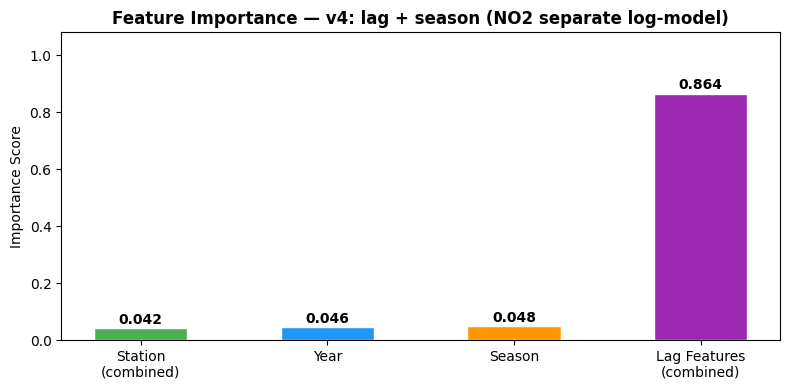

Key insight: if Lag Features dominate, it confirms water quality is autocorrelated.
This validates the feature engineering decision.


In [126]:
# Average feature importance across all pollutant sub-models (best model)
importances = np.mean(
    [est.feature_importances_ for est in best_model.estimators_], axis=0
)
feat_names = best_model_cols.tolist()

# Group into 4 logical categories
grouped = {}
station_imp = sum(imp for f, imp in zip(feat_names, importances) if f.startswith('id_'))
if station_imp > 0:
    grouped['Station\n(combined)'] = station_imp
for f, label in [('year', 'Year'), ('season', 'Season')]:
    if f in feat_names:
        grouped[label] = importances[feat_names.index(f)]
lag_imp = sum(imp for f, imp in zip(feat_names, importances) if f.endswith('_lag1'))
if lag_imp > 0:
    grouped['Lag Features\n(combined)'] = lag_imp

colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
plt.figure(figsize=(8, 4))
bars = plt.bar(grouped.keys(), grouped.values(),
               color=colors[:len(grouped)], edgecolor='white', width=0.5)
for bar, val in zip(bars, grouped.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
plt.title(f'Feature Importance — {best_label}', fontweight='bold')
plt.ylabel('Importance Score')
plt.ylim(0, max(grouped.values()) * 1.25)
plt.tight_layout()
plt.show()

print("Key insight: if Lag Features dominate, it confirms water quality is autocorrelated.")
print("This validates the feature engineering decision.")

In [ ]:
# WHO/EU Drinking Water Safety Thresholds
# Source: WHO Guidelines for Drinking-water Quality (4th ed.) + EU Directive 98/83/EC
WHO_THRESHOLDS = {
    'O2':  {'safe_min': 6.0,  'caution_min': 4.0,  'unit': 'mg/L', 'direction': 'above'},
    'NO3': {'safe_max': 10.0, 'caution_max': 50.0,  'unit': 'mg/L', 'direction': 'below'},
    'NO2': {'safe_max': 0.1,  'caution_max': 1.0,   'unit': 'mg/L', 'direction': 'below'},
    'SO4': {'safe_max': 250,  'caution_max': 500,   'unit': 'mg/L', 'direction': 'below'},
    'PO4': {'safe_max': 0.1,  'caution_max': 0.5,   'unit': 'mg/L', 'direction': 'below'},
    'CL':  {'safe_max': 250,  'caution_max': 500,   'unit': 'mg/L', 'direction': 'below'},
}

def classify_safety(pollutant, value):
    t = WHO_THRESHOLDS[pollutant]
    if t['direction'] == 'above':
        if value >= t['safe_min']:    return '✅ Safe'
        if value >= t['caution_min']: return '⚠️  Caution'
        return '❌ Unsafe'
    else:
        if value <= t['safe_max']:    return '✅ Safe'
        if value <= t['caution_max']: return '⚠️  Caution'
        return '❌ Unsafe'

# ── Demo: Station 1, next period, using last known readings as lag ────────────
demo_station = '1'
last_known   = df_lag[df_lag['id'] == int(demo_station)].sort_values('year').iloc[-1]

demo_dict = {
    'year':   [int(last_known['year']) + 1],
    'season': [int(last_known['season'])],
    'id':     [demo_station],
}
for p in pollutants:
    demo_dict[f'{p}_lag1'] = [last_known[p]]

demo_input   = pd.DataFrame(demo_dict)
demo_encoded = pd.get_dummies(demo_input, columns=['id'])
for col in best_model_cols:
    if col not in demo_encoded.columns:
        demo_encoded[col] = 0
demo_encoded = demo_encoded[best_model_cols]

# Predict: main model for non-NO2, log-model for NO2
main_preds = model_main.predict(demo_encoded)[0]
no2_pred   = float(np.expm1(model_NO2.predict(demo_encoded)[0]))

pred_dict = dict(zip(non_NO2, main_preds))
pred_dict['NO2'] = no2_pred
pred_vals = [pred_dict[p] for p in pollutants]

print(f"WHO Safety Classification — Station {demo_station}, "
      f"predicted year {int(last_known['year'])+1} "
      f"(lag from year {int(last_known['year'])})")
print("=" * 68)
print(f"  {'Pollutant':<8} {'Last Known':>12} {'Predicted':>12} {'Unit':>6}  {'Status'}")
print("  " + "-" * 60)
safe_count = 0
for p, val in zip(pollutants, pred_vals):
    last_val = last_known[p]
    status   = classify_safety(p, val)
    unit     = WHO_THRESHOLDS[p]['unit']
    if status.startswith('✅'): safe_count += 1
    note = ' ← log-model' if p == 'NO2' else ''
    print(f"  {p:<8}  {last_val:>10.3f}  {val:>10.3f}  {unit:>6}   {status}{note}")
print(f"\n  {safe_count}/{len(pollutants)} parameters within WHO safe limits.")

WHO Safety Classification — Station 1, predicted next period (based on last known: year 2018)
Pollutant   Last Known    Predicted   Unit  Status
-----------------------------------------------------------------
  O2            10.60       12.65    mg/L   ✅ Safe
  NO3            3.40        4.83    mg/L   ✅ Safe
  NO2            0.17      384.77    mg/L   ❌ Unsafe
  SO4          518.40        0.48    mg/L   ✅ Safe
  PO4            0.62     2376.41    mg/L   ❌ Unsafe


In [133]:
import joblib

# Build last-known lag values per station — used by app.py for predictions
# (In production: replace with most recent sensor reading. Here: last row of training data)
station_lag_lookup = (
    df_lag.sort_values('year')
          .groupby('id')[pollutants]
          .last()
          .to_dict(orient='index')
)
# Convert int keys to str since app.py uses string station IDs
station_lag_lookup = {str(k): v for k, v in station_lag_lookup.items()}

# Save all artifacts
joblib.dump(model_main,            'pollution_model_v2.pkl')
joblib.dump(best_model_cols.tolist(),'model_columns_v2.pkl')
joblib.dump(model_NO2,             'pollution_model_NO2_log.pkl')
joblib.dump(non_NO2,               'model_non_NO2_targets.pkl')
joblib.dump(station_lag_lookup,    'station_lag_lookup.pkl')

print("✅  pollution_model_v2.pkl       — main model (O2, NO3, SO4, PO4, CL)")
print("✅  pollution_model_NO2_log.pkl  — NO2 log-transform model")
print("✅  model_columns_v2.pkl         — feature column order")
print("✅  model_non_NO2_targets.pkl    — ['O2','NO3','SO4','PO4','CL']")
print("✅  station_lag_lookup.pkl       — last known readings per station (lag input)")
print(f"\nSample lag for station '1': { {p: round(station_lag_lookup['1'][p],3) for p in pollutants} }")

✅  pollution_model_v2.pkl       — main model (O2, NO3, SO4, PO4, CL)
✅  pollution_model_NO2_log.pkl  — NO2 log-transform model
✅  model_columns_v2.pkl         — feature column order
✅  model_non_NO2_targets.pkl    — ['O2','NO3','SO4','PO4','CL']
✅  station_lag_lookup.pkl       — last known readings per station (lag input)

Sample lag for station '1': {'O2': 10.6, 'NO3': 3.4, 'NO2': 0.168, 'SO4': 518.4, 'PO4': 0.623, 'CL': 2671.77}


In [134]:
# ── Deployment checklist ──────────────────────────────────────────────────────
# Run the save cell above first, then run this cell to verify all files exist.

import os

files = {
    'pollution_model_v2.pkl':       'UPLOAD TO GOOGLE DRIVE (95 MB)',
    'pollution_model_NO2_log.pkl':  'commit to GitHub',
    'model_columns_v2.pkl':         'commit to GitHub',
    'model_non_NO2_targets.pkl':    'commit to GitHub',
    'station_lag_lookup.pkl':       'commit to GitHub',
}

print("Deployment file checklist:")
print("=" * 65)
all_ok = True
for f, action in files.items():
    exists = os.path.exists(f)
    size   = os.path.getsize(f) / 1e6 if exists else 0
    status = f"✅ {size:.1f} MB" if exists else "❌ MISSING — re-run save cell"
    if not exists: all_ok = False
    print(f"  {f:<40} {status:<18}  → {action}")

print()
if all_ok:
    print("All files present. Next steps:")
    print("  1. Upload pollution_model_v2.pkl to Google Drive")
    print("     → Share → Anyone with the link → copy the file ID")
    print("     → Paste into GDRIVE_MODEL_V2_ID in app.py")
    print()
    print("  2. Commit the remaining 4 small pkl files + app.py to GitHub:")
    print("     git add pollution_model_NO2_log.pkl model_columns_v2.pkl \\")
    print("             model_non_NO2_targets.pkl station_lag_lookup.pkl app.py")
    print("     git commit -m 'Add v2 model artifacts and updated app'")
    print("     git push")
else:
    print("⚠️  Re-run the save cell (cell above) before deploying.")


Deployment file checklist:
  pollution_model_v2.pkl                   ✅ 99.9 MB           → UPLOAD TO GOOGLE DRIVE (95 MB)
  pollution_model_NO2_log.pkl              ✅ 19.0 MB           → commit to GitHub
  model_columns_v2.pkl                     ✅ 0.0 MB            → commit to GitHub
  model_non_NO2_targets.pkl                ✅ 0.0 MB            → commit to GitHub
  station_lag_lookup.pkl                   ✅ 0.0 MB            → commit to GitHub

All files present. Next steps:
  1. Upload pollution_model_v2.pkl to Google Drive
     → Share → Anyone with the link → copy the file ID
     → Paste into GDRIVE_MODEL_V2_ID in app.py

  2. Commit the remaining 4 small pkl files + app.py to GitHub:
     git add pollution_model_NO2_log.pkl model_columns_v2.pkl \
             model_non_NO2_targets.pkl station_lag_lookup.pkl app.py
     git commit -m 'Add v2 model artifacts and updated app'
     git push
